Тематика проекта: аналитика маркетплейса

Для тестирования была выбрана гипотеза, согласно которой для пользователей, пришедших из канала TikTok, на конверсию можно влиять при помощи финансовых стимуляций

Этапы проекта (продолжение):

5. Описание дизайна A/B-теста, определение метрик и статистических критериев
6. Загрузка и изучение датасетов, построение ER-диаграммы
7. Post-hoc анализ данных A/B-эксперимента

### Описание дизайна A/B-теста

#### Описание фичи и зона ее влияния на пользователей
Фича — предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok. Цель — повышение конверсии среди пользователей, привлечённых через канал TikTok. Бонус на первую покупку должен стимулировать пользователей совершать первую покупку => повышать конверсию

#### Продуктовая гипотеза
Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку

#### Метрики эксперимента:
1. **Ключевая метрика**
- Конверсия в первую покупку — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку
2. **Вспомогательные метрики**
- ARPU - средняя выручка на пользователя TikTok
- ARPPU - средняя выручка на покупателя TikTok 
- AOV - средний чек TikTok
3. **Барьерная метрика**
- Общая выручка от пользователей TikTok

#### Критерии успеха эксперимента
- Cтатистически значимый рост ключевой метрики в тестовой группе

#### Cегмент пользователей + способ набора пользователей в группы
Только пользователи, приходящие из канала TikTok во время проведения эксперимента. Способ набора пользователей в группы — rolling split (набор в группы по мере регистрации новых пользователей). Группы:
- Контрольная (A): пользователи TikTok без бонуса — 50% пользователей
- Тестовая (B): пользователи TikTok с бонусом на первую покупку — 50% пользователей  

#### Ограничения по MDE и длительности эксперимента
Период проведения — 3 недели, без предварительного расчета мощности и MDE

#### Статистический критерий
- Ключевая метрика — конверсия в первую покупку — используем Z-тест пропорций для двух групп
- Вспомогательная метрика 1 — средняя выручка на пользователя — используем t-тест Уэлча
- Вспомогательная метрика 2 — средняя выручка на покупателя — используем t-тест Уэлча
- Барьерная метрика — общая выручка — используем t-тест Уэлча

Отдельно рассмотрим работу со вспомогательной метрикой 3 — средним чеком по каналу TikTok. Это ratio-метрика (единица наблюдения — чек — не совпадает с единицей рандомизации — пользователь). Средний чек рассчитывается как (сумма чеков заказов / кол-во заказов), но один пользователь может сделать несколько заказов, поэтому числитель и знаменатель в формуле расчета могут быть скоррелированы

- При работе со вспомогательной метрикой 3 воспользуемся методом линеаризации. Поэтому в качестве статистического критерия сможем использовать t-тест, при этом выберем t-тест Уэлча 

---

### Описание данных

Таблицы с данными о пользователях, событиях и заказах идентичны таблицам с историческими данными.

Добавлена таблица `sessions_AB`:

| Поле | Описание |
|------|----------|
| `session_id` | Уникальный идентификатор сессии. |
| `user_id` | Уникальный идентификатор пользователя. |
| `session_start` | Дата и время начала сессии. |
| `os` | Операционная система устройства. |
| `device` | Тип устройства. |
| `region` | Регион пользователя. |
| `browser` | Браузер, используемый пользователем. |
| `country` | Страна пользователя. |
| `entry_path` | Путь входа (начальная страница сессии). |
| `path_start` | Путь начала отслеживания. |
| `utm_source` |  |
| `screen_size` | Разрешение экрана устройства. |
| `scroll_depth` | Глубина прокрутки. |
| `user_segment` | Сегмент пользователя (regular/premium и т.д.). |
| `utm_campaign_id` | Идентификатор рекламной кампании. |
| `session_week` | Неделя сессии. |
| `session_month` | Месяц сессии. |

Результаты сплита лежит в таблице `AB_split_users`

### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

import warnings
warnings.filterwarnings('ignore')

In [2]:
def display_with_heading(heading, data):
    '''
    Функция для красивого отображения
    датафреймов с заголовком сверху
    
    heading — (str) — заголовок
    data — (pandas dataframe) — dataframe
    '''
    
    print(f'{heading}:')
    display(data)

### Загрузка и предварительное изучение датасетов

План (по каждому из датасетов):
1. Загрузка датасетов, оценка значений в столбцах, типов данных, наличия пропусков
2. Изучение диапазонов значений в столбцах с численым типов данных, датами 
3. Изучение уникальных значений в столбцах с категориальным типом данных
4. Изучение наличия дубликатов

Т.к. таблицы с данными о пользователях, событиях и заказах идентичны таблицам с историческими данными, повторим для датасетов **events_AB**, **orders_AB**, **users_AB** действия, проведенные ранее

Датасет **AB_split_users**, изучим уникальные значения в столбце "group" (возможно, попали данные и о друггих тестах). Далее используем этот датасет при анализе аудитории эксперимента

Датасет **sessions_AB** изучим подробнее, добавим его на ER-диаграмму

#### Датасет users_AB

In [3]:
try:
    users_AB = pd.read_csv(
        'datasets/datasets_AB/AB_users.csv',
        parse_dates=[
            'registration_date', 'cohort_month', 
            'cohort_week',
        ]
    )
    
except:
    users_AB = pd.read_csv(
        'https://code.s3.yandex.net/datasets/pa_diploma_users_AB.csv',
        parse_dates=[
            'registration_date', 'cohort_month', 
            'cohort_week',
        ]
    )

display_with_heading(
    'Датафрейм users_AB, первые 5 строк',
    users_AB.head()
)

print('Информация о датафрейме users_AB:\n')
users_AB.info()

# изучим диапазоны значений
# численных столбцов
with pd.option_context('display.float_format', '{:.2f}'.format):
    display_with_heading(
        '\nДиапазон столбцов с датами и численными значениями',
        users_AB.describe(exclude=object).loc[['min', 'max']]
    )

# изучим уникальные значения
# категориальных столбцов
category_columns_users = [
    'gender', 'region', 
    'acq_channel', 'buyer_segment',
    'os', 'device', 'browser', 
    'country', 'user_segment'
]

for column in category_columns_users:
    display_with_heading(
        f'Уникальные значения столбца {column}',
        list(users_AB[column].unique())
    )
    print('\n')

# посмотрим на наличие дубликатов
print(
    'Кол-во полных дубликатов в датафрейме:',
    users_AB.duplicated().sum()
)

Датафрейм users_AB, первые 5 строк:


,user_id,registration_date,os,age,device,gender,region,browser,country,acq_channel,campaign_id,user_segment,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,Android,49,mobile,M,Екатеринбург,Edge,Россия,TikTok,10.0,спящий,one_time,2024-01-01,2024-01-01
1,22,2024-01-01 17:13:00,iOS,50,tablet,M,Санкт-Петербург,Chrome,Россия,TikTok,43.0,VIP,one_time,2024-01-01,2024-01-01
2,26,2024-01-01 21:15:00,iOS,60,desktop,F,Москва,Firefox,Россия,TikTok,27.0,активный,rare,2024-01-01,2024-01-01
3,33,2024-01-01 14:43:00,iOS,31,desktop,M,Екатеринбург,Firefox,Россия,TikTok,15.0,новичок,rare,2024-01-01,2024-01-01
4,39,2024-01-01 01:13:00,Android,44,tablet,M,Санкт-Петербург,Firefox,Россия,TikTok,15.0,спящий,rare,2024-01-01,2024-01-01


Информация о датафрейме users_AB:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22196 entries, 0 to 22195
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            22196 non-null  int64         
 1   registration_date  22196 non-null  datetime64[ns]
 2   os                 22196 non-null  object        
 3   age                22196 non-null  int64         
 4   device             22196 non-null  object        
 5   gender             22196 non-null  object        
 6   region             22196 non-null  object        
 7   browser            22196 non-null  object        
 8   country            22196 non-null  object        
 9   acq_channel        22196 non-null  object        
 10  campaign_id        22196 non-null  float64       
 11  user_segment       22196 non-null  object        
 12  buyer_segment      22196 non-null  object        
 13  cohort_week        22196 n

,user_id,registration_date,age,campaign_id,cohort_week,cohort_month
min,18.00,2024-01-01 01:13:00,18.00,1.00,2024-01-01 00:00:00,2024-01-01 00:00:00
max,48907.00,2025-01-26 23:41:00,70.00,50.00,2025-01-20 00:00:00,2025-01-01 00:00:00


Уникальные значения столбца gender:


...



Уникальные значения столбца country:


['Россия']



Уникальные значения столбца user_segment:


['спящий', 'VIP', 'активный', 'новичок']



Кол-во полных дубликатов в датафрейме: 0


#### Промежуточный вывод по датафрейму users_AB: 
- данные выгружены верно (присутствуют все столбцы, значения соответствуют смыслу столбцов)
- типы данных подходящие
- пропусков нет
- диапазоны значений нормальные (регистрация с начала января 2024 по конец января 2025, возраст от 18 до 70, диапазоны cohort_week и cohort_month совпадают с диапазоном дат регистрации)
- значение в acq_channel — только TikTok, пользователи из других каналов привлечения не попали
- в категориальных столбцах неявных дубликатов нет
- полных дубликатов в датафрейме нет

Также относительно датафрейма users с историческими данными добавились параметры, это было учтено при изучении данных

#### Датасет events_AB

In [4]:
try:
    events_AB = pd.read_csv(
        'datasets/datasets_AB/AB_events.csv',
        parse_dates=[
            'event_date', 'event_month', 
            'event_week',
        ]
    )
    
except:
    events_AB = pd.read_csv(
        'https://code.s3.yandex.net/datasets/pa_diploma_events_AB.csv',
        parse_dates=[
            'event_date', 'event_month', 
            'event_week',
        ]
    )

display_with_heading(
    'Датафрейм events_AB, первые 5 строк',
    events_AB.head()
)

print('Информация о датафрейме events_AB:\n')
events_AB.info()

# изучим диапазоны значений
# численных столбцов
with pd.option_context('display.float_format', '{:.2f}'.format):
    display_with_heading(
        '\nДиапазон столбцов с датами и численными значениями',
        events_AB.describe(exclude=object).loc[['min', 'max']]
    )

# изучим уникальные значения
# категориальных столбцов
category_columns_events_AB = [
    'event_type', 'os', 
    'device', 'user_segment',
]

for column in category_columns_events_AB:
    display_with_heading(
        f'Уникальные значения столбца {column}',
        list(events_AB[column].unique())
    )
    print('\n')

# посмотрим на наличие дубликатов
print(
    'Кол-во полных дубликатов в датафрейме:',
    events_AB.duplicated().sum()
)

Датафрейм events_AB, первые 5 строк:


,event_id,session_id,user_id,event_date,event_type,os,device,event_index,user_segment,product_name,event_week,event_month
0,3132,479,100,2024-01-01 15:23:56,page_view,iOS,mobile,1,regular,NaN,2024-01-01,2024-01-01
1,3133,479,100,2024-01-01 15:24:01,product_view,iOS,mobile,2,regular,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,479,100,2024-01-01 15:24:10,product_click,iOS,mobile,3,regular,Куртка детская,2024-01-01,2024-01-01
3,3135,479,100,2024-01-01 15:25:10,add_to_cart,iOS,mobile,4,regular,Балетки классические,2024-01-01,2024-01-01
4,3136,479,100,2024-01-01 15:25:46,checkout_start,iOS,mobile,5,regular,NaN,2024-01-01,2024-01-01


Информация о датафрейме events_AB:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831231 entries, 0 to 831230
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      831231 non-null  int64         
 1   session_id    831231 non-null  int64         
 2   user_id       831231 non-null  int64         
 3   event_date    831231 non-null  datetime64[ns]
 4   event_type    831231 non-null  object        
 5   os            831231 non-null  object        
 6   device        831231 non-null  object        
 7   event_index   831231 non-null  int64         
 8   user_segment  831231 non-null  object        
 9   product_name  409054 non-null  object        
 10  event_week    831231 non-null  datetime64[ns]
 11  event_month   831231 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(4), object(5)
memory usage: 76.1+ MB

Диапазон столбцов с датами и численными значениями:


,event_id,session_id,user_id,event_date,event_index,event_week,event_month
min,1.00,1.00,2.00,2024-01-01 15:23:56,1.00,2024-01-01 00:00:00,2024-01-01 00:00:00
max,873327.00,140632.00,48901.00,2025-01-26 23:59:34,14.00,2025-01-20 00:00:00,2025-01-01 00:00:00


Уникальные значения столбца event_type:


...



Уникальные значения столбца device:


['mobile', 'desktop', 'tablet']



Уникальные значения столбца user_segment:


['regular', 'rare', 'medium', 'one_time']



Кол-во полных дубликатов в датафрейме: 0


**Промежуточный вывод по изучению датасета events_AB:**
- есть id сессии, это будет полезно при построении воронки
- данные выгружены верно (присутствуют все столбцы, значения соответствуют смыслу столбцов)
- типы данных подходящие 
- есть пропуски в столбце `product_name`, но они объяснимы (не для всех типов события можно указать наименование продукта)
- диапазоны значений нормальные
- появился параметр `event_index` — в дальнейшем изучить, зависит ли он от порядка событий
- неявных дубликатов по столбцам с категорийными данными нет
- полных дубликатов нет

Также относительно датафрейма events с историческими данными добавились параметры, это было учтено при изучении данных

#### Датасет orders_AB

In [5]:
try:
    orders_AB = pd.read_csv(
        'datasets/datasets_AB/AB_orders.csv',
        parse_dates=[
            'order_date', 'order_month', 
            'order_week',
        ],
    )
    
except:
    orders_AB = pd.read_csv(
        'https://code.s3.yandex.net/datasets/pa_diploma_orders_AB.csv',
        parse_dates=[
            'order_date', 'order_month', 
            'order_week',
        ],
    )

orders_AB['order_date'] = (
    orders_AB['order_date'].apply(
        pd.to_datetime,
        errors='coerce',
    )
)
    
display_with_heading(
    'Датафрейм orders_AB, первые 5 строк',
    orders_AB.head()
)

print('Информация о датафрейме orders_AB:\n')
orders_AB.info()

# изучим диапазоны значений
# численных столбцов
with pd.option_context('display.float_format', '{:.2f}'.format):
    display_with_heading(
        '\nДиапазон столбцов с датами и численными значениями',
        orders_AB.describe(exclude=object).loc[['min', 'max']]
    )

# изучим кол-во наименований категорий
print(
    '\nКол-во уникальных наименований категорий товаров:',
    orders_AB['category_name'].nunique()
)

# посмотрим на наличие дубликатов
print(
    '\nКол-во полных дубликатов в датафрейме:',
    orders_AB.duplicated().sum()
)

Датафрейм orders_AB, первые 5 строк:


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


Информация о датафрейме orders_AB:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       33280 non-null  int64         
 1   user_id        33280 non-null  int64         
 2   order_date     33280 non-null  datetime64[ns]
 3   product_name   33280 non-null  object        
 4   quantity       33280 non-null  int64         
 5   unit_price     33280 non-null  float64       
 6   total_price    33280 non-null  float64       
 7   category_name  33280 non-null  object        
 8   order_week     33280 non-null  datetime64[ns]
 9   order_month    33280 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.5+ MB

Диапазон столбцов с датами и численными значениями:


,order_id,user_id,order_date,quantity,unit_price,total_price,order_week,order_month
min,1.00,3.00,2024-01-01 08:03:45,1.00,218.82,218.82,2024-01-01 00:00:00,2024-01-01 00:00:00
max,38848.00,48789.00,2025-01-26 23:07:50,3.00,63932.38,191797.14,2025-01-20 00:00:00,2025-01-01 00:00:00



Кол-во уникальных наименований категорий товаров: 25

Кол-во полных дубликатов в датафрейме: 0


**Промежуточный вывод по изучению датасета orders_AB:**
- данные выгружены верно (присутствуют все столбцы, значения соответствуют смыслу столбцов)
- типы данных подходящие
- пропусков нет
- диапазоны значений нормальные
- полных дубликатов в датафрейме нет

#### Датасет AB_split_users

In [6]:
try:
    AB_split_users = pd.read_csv(
        'datasets/datasets_AB/AB_split_users.csv',
    )
    
except:
    AB_split_users = pd.read_csv(
        'https://code.s3.yandex.net/datasets/pa_diploma_AB_split_users.csv',
    )
    
display_with_heading(
    'Датафрейм AB_split_users, первые 5 строк',
    AB_split_users.head()
)

print('Информация о датафрейме AB_split_users:\n')
AB_split_users.info()

# изучим диапазоны значений
# численных столбцов
with pd.option_context('display.float_format', '{:.2f}'.format):
    display_with_heading(
        '\nДиапазон столбцов с датами и численными значениями',
        AB_split_users.describe(exclude=object).loc[['min', 'max']]
    )

# изучим уникальные значения
# столбца group:
display_with_heading(
    '\nУникальные значения столбца group',
    list(AB_split_users['group'].unique())
)

# посмотрим на наличие дубликатов
print(
    '\nКол-во полных дубликатов в датафрейме:',
    AB_split_users.duplicated().sum()
)

Датафрейм AB_split_users, первые 5 строк:


,user_id,group
0,44965,control
1,44967,control
2,44968,control
3,44969,treatment
4,44970,control


Информация о датафрейме AB_split_users:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2968 non-null   int64 
 1   group    2968 non-null   object
dtypes: int64(1), object(1)
memory usage: 46.5+ KB

Диапазон столбцов с датами и численными значениями:


,user_id
min,44965.00
max,48907.00



Уникальные значения столбца group:


['control', 'treatment']


Кол-во полных дубликатов в датафрейме: 0


**Промежуточный вывод по изучению датасета AB_split_users:**
- данные выгружены верно (присутствуют все столбцы, значения соответствуют смыслу столбцов)
- типы данных подходящие
- пропусков нет
- полных дубликатов в датафрейме нет
- в эксперименте около 3000 пользователей<br>
<br>
- необходимо будет отфильтровать все предыдущие датасеты, оставив действия только пользователей, участвующих в эксперименте

#### Датасет sessions_AB

In [7]:
try:
    sessions_AB = pd.read_csv(
        'datasets/datasets_AB/AB_sessions.csv',
        parse_dates=[
            'session_start', 'session_week',
            'session_month',
        ],
    )
    
except:
    sessions_AB = pd.read_csv(
        'https://code.s3.yandex.net/datasets/pa_diploma_sessions_AB.csv',
        parse_dates=[
            'session_start', 'session_week',
            'session_month',
        ],
    )

sessions_AB['session_start'] = (
    sessions_AB['session_start'].apply(
        pd.to_datetime,
        errors='coerce',
    )
)
    
display_with_heading(
    'Датафрейм sessions_AB, первые 5 строк',
    sessions_AB.head()
)

print('Информация о датафрейме sessions_AB:\n')
sessions_AB.info()

# изучим диапазоны значений
# численных столбцов
with pd.option_context('display.float_format', '{:.2f}'.format):
    display_with_heading(
        '\nДиапазон столбцов с датами и численными значениями',
        sessions_AB.describe(exclude=object).loc[['min', 'max']]
    )
    
# изучим уникальные значения
# категориальных столбцов
category_columns_sessions_AB = [
    'os', 'device',
    'region', 'browser',
    'country', 'entry_path',
    'utm_source', 'screen_size',
    'user_segment'
]

for column in category_columns_sessions_AB:
    display_with_heading(
        f'Уникальные значения столбца {column}',
        list(sessions_AB[column].unique())
    )
    print('\n')
    
# изучим уникальные значения
# столбца path_start, не обращая
# внимания на знаки / и цифры
print(
    'Уникальные значения пути начала отслеживания (path_start) без / и цифр:\n',
    sessions_AB['path_start']
        .str.replace('/', '')
        .str.replace('\d+', '', regex=True)
        .unique()
)

# посмотрим на наличие дубликатов
print(
    '\nКол-во полных дубликатов в датафрейме:',
    sessions_AB.duplicated().sum()
)

Датафрейм sessions_AB, первые 5 строк:


,session_id,user_id,session_start,os,device,region,browser,country,entry_path,path_start,utm_source,screen_size,scroll_depth,user_segment,utm_campaign_id,session_week,session_month
0,705,160,2024-01-12 02:30:37,Windows,mobile,Москва,Safari,Россия,/home,/recommend/10,unknown,768x1024,51,regular,14.0,2024-01-08,2024-01-01
1,706,160,2024-01-10 06:04:41,Windows,mobile,Москва,Safari,Россия,/home,/sale/2,unknown,375x667,71,regular,14.0,2024-01-08,2024-01-01
2,707,160,2024-01-23 03:31:16,Windows,mobile,Москва,Safari,Россия,/checkout,/click/20,unknown,768x1024,84,regular,14.0,2024-01-22,2024-01-01
3,708,160,2024-01-18 13:43:45,Windows,mobile,Москва,Safari,Россия,/category,/campaign/20,unknown,768x1024,20,regular,14.0,2024-01-15,2024-01-01
4,709,160,2024-01-21 01:09:58,Windows,mobile,Москва,Safari,Россия,/promo,/sale/3,unknown,1366x768,88,regular,14.0,2024-01-15,2024-01-01


Информация о датафрейме sessions_AB:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127407 entries, 0 to 127406
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   session_id       127407 non-null  int64         
 1   user_id          127407 non-null  int64         
 2   session_start    127407 non-null  datetime64[ns]
 3   os               127407 non-null  object        
 4   device           127407 non-null  object        
 5   region           127407 non-null  object        
 6   browser          127407 non-null  object        
 7   country          127407 non-null  object        
 8   entry_path       127407 non-null  object        
 9   path_start       127407 non-null  object        
 10  utm_source       127407 non-null  object        
 11  screen_size      127407 non-null  object        
 12  scroll_depth     127407 non-null  int64         
 13  user_segment     127407 non-null  ob

,session_id,user_id,session_start,scroll_depth,utm_campaign_id,session_week,session_month
min,1.00,2.00,2024-01-01 08:34:27,10.00,1.00,2024-01-01 00:00:00,2024-01-01 00:00:00
max,140632.00,48901.00,2025-01-26 23:58:24,100.00,50.00,2025-01-20 00:00:00,2025-01-01 00:00:00


Уникальные значения столбца os:


...



Уникальные значения столбца screen_size:


['768x1024', '375x667', '1366x768', '1920x1080']



Уникальные значения столбца user_segment:


['regular', 'rare', 'medium', 'one_time']



Уникальные значения пути начала отслеживания (path_start) без / и цифр:
 ['recommend' 'sale' 'click' 'campaign']

Кол-во полных дубликатов в датафрейме: 0


**Промежуточный вывод по изучению датасета AB_split_users:**
- данные выгружены верно (присутствуют все столбцы, значения соответствуют смыслу столбцов)
- типы данных подходящие
- диапазоны данных нормальные
- есть пропуски в utm_campaign_id, менее 1% строк с пропусками, оставим как есть
- полных дубликатов в датафрейме нет
- неявных дубликатов в столбцах с категорийными данными нет<br>
<br>
- `utm_source` — столбец содержит только значения "unknown" — можно удалить

## Вывод по изучению датасетов

Во всех датасетах:
- данные выгружены верно (присутствуют все столбцы, значения соответствуют смыслу столбцов)
- типы данных подходящие
- пропусков либо нет, либо они объяснимы/составляют малую долю (менее 1%) и оставлены
- полных дубликатов нет
- неявных дубликатов по категорийным столбцам нет
- диапазоны значений нормальные
- данные в категорийных столбцах совпадают между датасетами

Важно:
- в датафреймах users, orders, events, sessions есть все пользователи, пришедшие из канала TikTok — т.е. часть пользователей лишняя; отфильтруем их по id пользователей, участвующих в эксперименте

Дополнительно:
- совпадают диапазоны столбцов `campaign_id` **users_AB** и `utm_campaign_id` **sessions_AB**, можно предположить, что это разные названия одной и той же сущности

### Действия с датасетами по результатам их изучения

1. Отфильтруем users_AB, orders_AB, events_AB, sessions_AB по user_id пользователей, участвующих в тесте
2. Удалим столбец `utm_source` из sessions_AB
3. Сформируем ER-диаграмму для удобства дальнейшей работы

In [8]:
users_AB = (
    users_AB[
        users_AB['user_id'].isin(AB_split_users['user_id'])
    ]
)

print(
    f'Размер датасета users_AB до фильтрации: {users_AB.shape[0]}'
    + f'\nРазмер датасета users_AB после фильтрации: {users_AB.shape[0]}'
)

Размер датасета users_AB до фильтрации: 2968
Размер датасета users_AB после фильтрации: 2968


In [9]:
orders_AB = (
    orders_AB[
        orders_AB['user_id'].isin(AB_split_users['user_id'])
    ]
)

print(
    f'Размер датасета orders_AB до фильтрации: {orders_AB.shape[0]}'
    + f'\nРазмер датасета orders_AB после фильтрации: {orders_AB.shape[0]}'
)

Размер датасета orders_AB до фильтрации: 255
Размер датасета orders_AB после фильтрации: 255


In [10]:
events_AB = (
    events_AB[
        events_AB['user_id'].isin(AB_split_users['user_id'])
    ]
)

print(
    f'Размер датасета events_AB до фильтрации: {events_AB.shape[0]}'
    + f'\nРазмер датасета events_AB после фильтрации: {events_AB.shape[0]}'
)

Размер датасета events_AB до фильтрации: 4349
Размер датасета events_AB после фильтрации: 4349


In [11]:
sessions_AB_with_add_columns = (
    sessions_AB[
        sessions_AB['user_id'].isin(AB_split_users['user_id'])
    ]
)

sessions_AB = sessions_AB_with_add_columns.drop(columns=['utm_source'])

print(
    f'Размер датасета sessions_AB до фильтрации: {sessions_AB.shape[0]}'
    + f'\nРазмер датасета sessions_AB после фильтрации: {sessions_AB.shape[0]}'
)

Размер датасета sessions_AB до фильтрации: 812
Размер датасета sessions_AB после фильтрации: 812


### ER-диаграмма

### Анализ результатов эксперимента

План анализа:
1. Анализ аудитории эксперимента (проверка корректности сплита)
2. Сравнение воронок событий в тестовой и контрольной группах
3. Анализ метрик А/В-эксперимента (проверка статистической значимости изменения ключевой метрики, т.к. это критерий успешности теста; расчет вспомогательных и барьерной метрик, проверка статистической значимости при ухудшении метрики)

### 1.1 Анализ аудитории эксперимента

Проверим, что группы не пересекаются, проверим размеры групп; затем объединим таблицы **users_AB** и **AB_split_users**, разбиение по категорийным признакам

In [12]:
# проверим, что нет пользователей,
# которые находятся одновременно в
# двух экспериментальных группах

intersection = (
    set(AB_split_users[AB_split_users['group']=='control']['user_id'])
    & set(AB_split_users[AB_split_users['group']=='test']['user_id'])
)

if intersection:
    print(f'Пользователи, попавшие в обе группы: {intersection}')
else:
    print('Группы не пересекаются')

Группы не пересекаются


In [13]:
# проверим равенство долей с помощью 
# статистического теста Z-теста пропорций
# H_0: статистически значимого различия
# долей нет; H_1: есть (двуст. альт. гип.)

control_size = (
    AB_split_users[
        AB_split_users['group'] == 'control'
    ].shape[0]
)
print(f'Размер контрольной группы: {control_size}')

test_size = (
    AB_split_users[
        AB_split_users['group'] == 'treatment'
    ].shape[0]
)
print(f'Размер тестовой группы: {test_size}')

total_users_in_exp = AB_split_users.shape[0]
print(f'Кол-во пользователей в эксперименте: {total_users_in_exp}')

stat, pval = proportions_ztest(
    [control_size, test_size],
    [total_users_in_exp, total_users_in_exp],
    alternative='two-sided'
)

print(f'\nДоля контроля: {round(100 * control_size / total_users_in_exp)}%')
print(f'Доля теста: {round(100 * test_size / total_users_in_exp)}%')

alpha = 0.05 # возьмем стандартное значение

if pval < alpha:
    print('\nМежду долями в группах есть стат. значимая разницы\n')
else:
    print('\nНет статистически значимой разницы между долями в группах\n')

Размер контрольной группы: 1503
Размер тестовой группы: 1465
Кол-во пользователей в эксперименте: 2968

Доля контроля: 51%
Доля теста: 49%

Нет статистически значимой разницы между долями в группах



**Промежуточный вывод:** 

Группы не пересекаются, размеры групп близки, нет статистически значимой разницы между долями в группах

### 1.2 Проверим распределение по категориям пользователей в тесте и контроле

Т.к. размер групп небольшой и при делении на группы не использовали стратифицированную рандомизацию, необходимо проверить доли подгрупп по таким признакам, как возрастной сегмент, утройство, сегмент пользователей и др. в тестовой и контрольной группе. Сильный перекос между долями в группе может отразиться на результате A/B-эксперимента, поэтому необходимо понимать распределение между группами для верной интерпретации результатов

Проверяем равенство долей, поэтому будем использовать Z-тест пропорций, гипотезы:
- H_0: статистически значимого различия долей нет (доля группы в тестовой выборке и доля группы в контрольной выборке равны); 
- H_1: статистически значимое различие долей есть (доля группы в тестовой выборке и доля группы в контрольной выборке не равны)(двусторонняя альтернативная гипотеза)

alpha = 0.05, используем поправку Бонферрони

In [14]:
# объединим таблицы
users_AB_with_group = pd.merge(
    users_AB,
    AB_split_users,
    how='left',
    on='user_id'
)

display_with_heading(
    'users_AB с информацией о группе',
    users_AB_with_group.head()
)

users_AB с информацией о группе:


,user_id,registration_date,os,age,device,gender,region,browser,country,acq_channel,campaign_id,user_segment,buyer_segment,cohort_week,cohort_month,group
0,44965,2025-01-01 18:10:00,iOS,66,desktop,M,Новосибирск,Safari,Россия,TikTok,14.0,новичок,one_time,2024-12-30,2025-01-01,control
1,44967,2025-01-01 11:29:00,iOS,70,tablet,M,Московская область,Firefox,Россия,TikTok,13.0,новичок,rare,2024-12-30,2025-01-01,control
2,44968,2025-01-01 13:05:00,Android,68,mobile,F,Нижний Новгород,Edge,Россия,TikTok,10.0,спящий,regular,2024-12-30,2025-01-01,control
3,44969,2025-01-01 00:23:00,Windows,24,mobile,F,Краснодар,Chrome,Россия,TikTok,8.0,спящий,medium,2024-12-30,2025-01-01,treatment
4,44970,2025-01-01 06:33:00,iOS,50,tablet,M,Санкт-Петербург,Chrome,Россия,TikTok,2.0,спящий,regular,2024-12-30,2025-01-01,control


In [15]:
# создадим датафрейм с размерами групп
group_sizes = pd.DataFrame.from_dict(
    {'control': control_size, 'treatment': test_size},
    orient='index',
    columns=['total_users'],
).reset_index(names='group')

In [16]:
def groups_division(parameter):
    '''
    Функция для оценки долей подгрупп по
    различным параметрам (например, возрастной 
    сегмент, устройство, операционная система)
    между тестовой и контрольной группами
    
    parameter — str — название столбца c 
    категорийным признаком, доли по которому
    изучаем
    '''
    # сгруппируем по группе в 
    # эксперименте и параметру
    users_AB_with_group_gr = (
        users_AB_with_group
            .groupby(['group', parameter])
            .agg(users=('user_id', 'nunique'))
            .reset_index()
    )

    # объединим информацию с
    # инф-ей о размерах групп
    users_AB_with_group_gr = pd.merge(
        users_AB_with_group_gr,
        group_sizes,
        on='group',
        how='left'
    )

    users_AB_with_group_gr['users_%'] = round(
        100 * users_AB_with_group_gr['users']
        / users_AB_with_group_gr['total_users'], 1
    )

    display_with_heading(
        f'Распределение по {parameter} в экспериментальных группах',
        users_AB_with_group_gr
    )
    
    # визуализация
    plt.figure(figsize=(8, 8))

    sns.barplot(
        data=users_AB_with_group_gr, 
        x="users_%", y=parameter, 
        hue="group",
    )

    plt.title(
        f'Распределение по {parameter} в test и control',
        fontsize=16,
        pad=12,
    )

    plt.xlabel(
        'Доля пользователей',
        fontsize=14,
        labelpad=12,
    )

    plt.ylabel(
        ' ',
    )

    plt.tick_params(
       labelsize=12 
    )

    plt.legend(
        fontsize=13,
        framealpha=1,
        loc=(1.01, 0.45)
    )

    plt.grid()
    plt.show()
    
    # проверим равенство долей с помощью
    # статистического теста Z-теста пропорций
    # H_0: статистически значимого различия
    # долей нет; H_1: есть (двуст. альт. гип.)

    for value in users_AB_with_group_gr[parameter].unique():
        data = users_AB_with_group_gr[users_AB_with_group_gr[parameter]==value]
        
        control_value = data[data.group == 'control']['users'][:]
        test_value = data[data.group == 'treatment']['users']
        
        control_size = data[data.group == 'control']['total_users']
        test_size = data[data.group == 'treatment']['total_users']
        
        stat, pval = proportions_ztest(
            [control_value, test_value],
            [control_size, test_size],
            alternative='two-sided'
        )

        alpha = (
            0.05 / users_AB_with_group_gr[parameter].nunique()
        ) # возьмем стандартное значение и введем поправку Бонферони

        if pval < alpha:
            print(f'Между долями {value} в группах есть стат. значимая разница')
        else:
            print(f'Нет статистически значимой разницы между долями {value} в группах')
            
    print('\n\n')

Распределение по gender в экспериментальных группах:


,group,gender,users,total_users,users_%
0,control,F,745,1503,49.6
1,control,M,758,1503,50.4
2,treatment,F,766,1465,52.3
3,treatment,M,699,1465,47.7


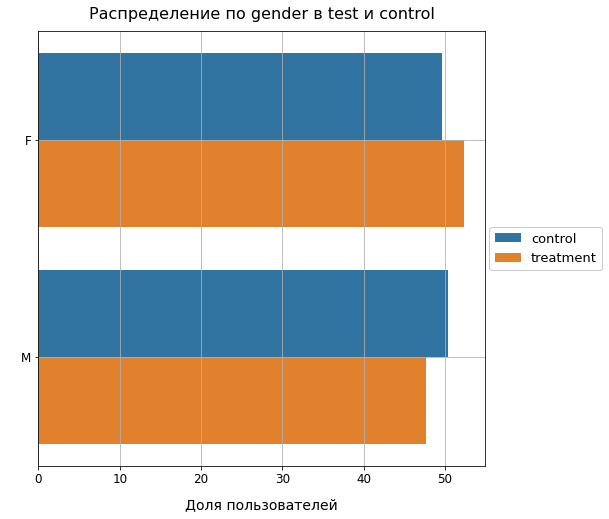

Нет статистически значимой разницы между долями F в группах
Нет статистически значимой разницы между долями M в группах



Распределение по region в экспериментальных группах:


,group,region,users,total_users,users_%
0,control,Другие регионы,487,1503,32.4
1,control,Екатеринбург,68,1503,4.5
2,control,Краснодар,63,1503,4.2
3,control,Москва,371,1503,24.7
4,control,Московская область,115,1503,7.7
5,control,Нижний Новгород,65,1503,4.3
6,control,Новосибирск,65,1503,4.3
7,control,Ростов-на-Дону,39,1503,2.6
8,control,Санкт-Петербург,230,1503,15.3
9,treatment,Другие регионы,494,1465,33.7


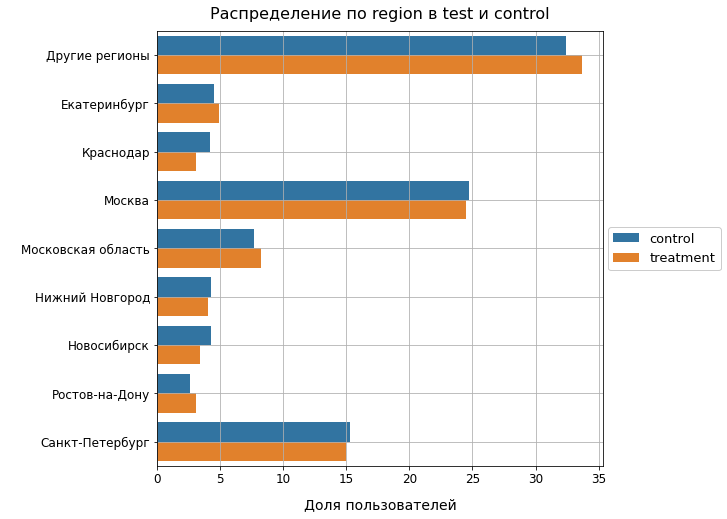

Нет статистически значимой разницы между долями Другие регионы в группах
Нет статистически значимой разницы между долями Екатеринбург в группах
Нет статистически значимой разницы между долями Краснодар в группах
Нет статистически значимой разницы между долями Москва в группах
Нет статистически значимой разницы между долями Московская область в группах
Нет статистически значимой разницы между долями Нижний Новгород в группах
Нет статистически значимой разницы между долями Новосибирск в группах
Нет статистически значимой разницы между долями Ростов-на-Дону в группах
Нет статистически значимой разницы между долями Санкт-Петербург в группах



Распределение по buyer_segment в экспериментальных группах:


,group,buyer_segment,users,total_users,users_%
0,control,medium,539,1503,35.9
1,control,one_time,215,1503,14.3
2,control,rare,456,1503,30.3
3,control,regular,293,1503,19.5
4,treatment,medium,530,1465,36.2
5,treatment,one_time,246,1465,16.8
6,treatment,rare,431,1465,29.4
7,treatment,regular,258,1465,17.6


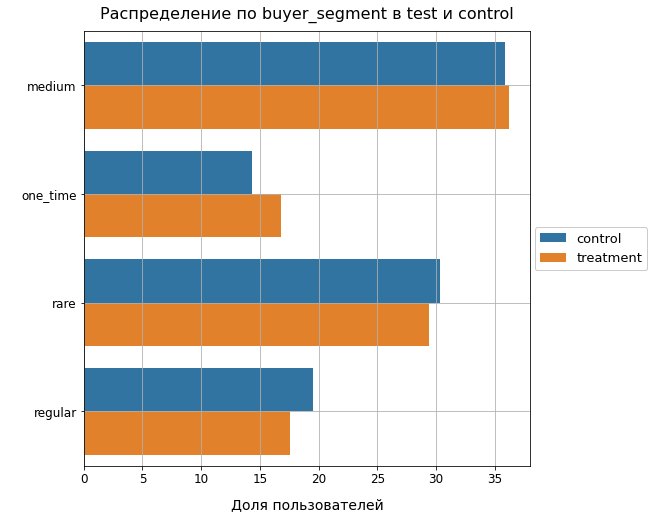

Нет статистически значимой разницы между долями medium в группах
Нет статистически значимой разницы между долями one_time в группах
Нет статистически значимой разницы между долями rare в группах
Нет статистически значимой разницы между долями regular в группах



Распределение по os в экспериментальных группах:


,group,os,users,total_users,users_%
0,control,Android,369,1503,24.6
1,control,Windows,358,1503,23.8
2,control,iOS,401,1503,26.7
3,control,macOS,375,1503,25.0
4,treatment,Android,339,1465,23.1
5,treatment,Windows,366,1465,25.0
6,treatment,iOS,375,1465,25.6
7,treatment,macOS,385,1465,26.3


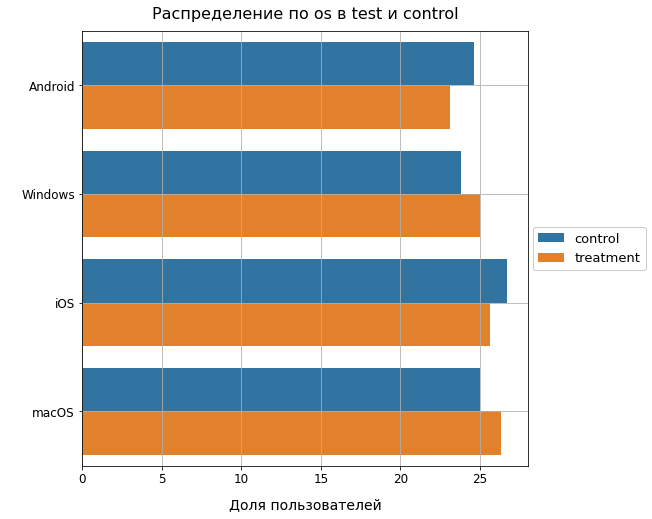

Нет статистически значимой разницы между долями Android в группах
Нет статистически значимой разницы между долями Windows в группах
Нет статистически значимой разницы между долями iOS в группах
Нет статистически значимой разницы между долями macOS в группах



Распределение по device в экспериментальных группах:


,group,device,users,total_users,users_%
0,control,desktop,492,1503,32.7
1,control,mobile,537,1503,35.7
2,control,tablet,474,1503,31.5
3,treatment,desktop,471,1465,32.2
4,treatment,mobile,454,1465,31.0
5,treatment,tablet,540,1465,36.9


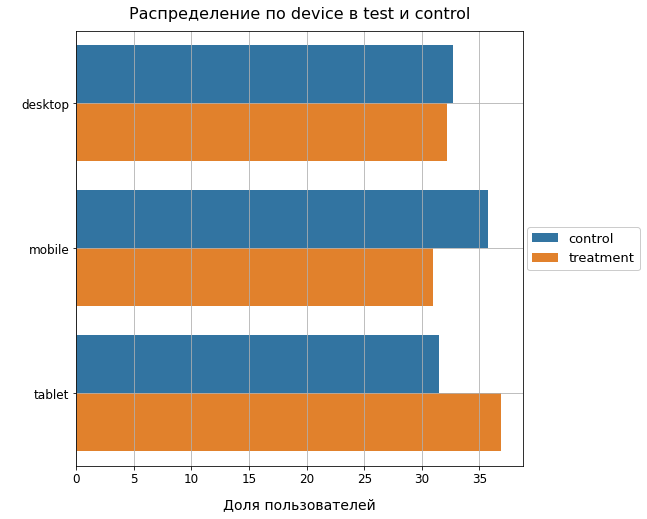

Нет статистически значимой разницы между долями desktop в группах
Между долями mobile в группах есть стат. значимая разница
Между долями tablet в группах есть стат. значимая разница



Распределение по browser в экспериментальных группах:


,group,browser,users,total_users,users_%
0,control,Chrome,364,1503,24.2
1,control,Edge,351,1503,23.4
2,control,Firefox,392,1503,26.1
3,control,Safari,396,1503,26.3
4,treatment,Chrome,380,1465,25.9
5,treatment,Edge,347,1465,23.7
6,treatment,Firefox,389,1465,26.6
7,treatment,Safari,349,1465,23.8


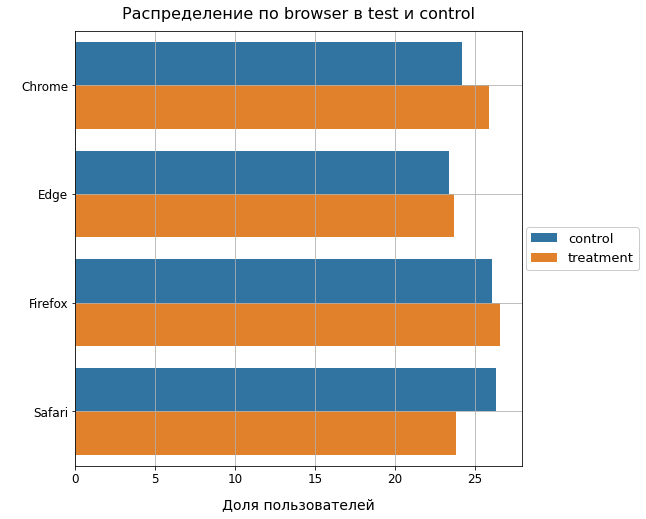

Нет статистически значимой разницы между долями Chrome в группах
Нет статистически значимой разницы между долями Edge в группах
Нет статистически значимой разницы между долями Firefox в группах
Нет статистически значимой разницы между долями Safari в группах



Распределение по user_segment в экспериментальных группах:


,group,user_segment,users,total_users,users_%
0,control,VIP,430,1503,28.6
1,control,активный,347,1503,23.1
2,control,новичок,376,1503,25.0
3,control,спящий,350,1503,23.3
4,treatment,VIP,364,1465,24.8
5,treatment,активный,368,1465,25.1
6,treatment,новичок,360,1465,24.6
7,treatment,спящий,373,1465,25.5


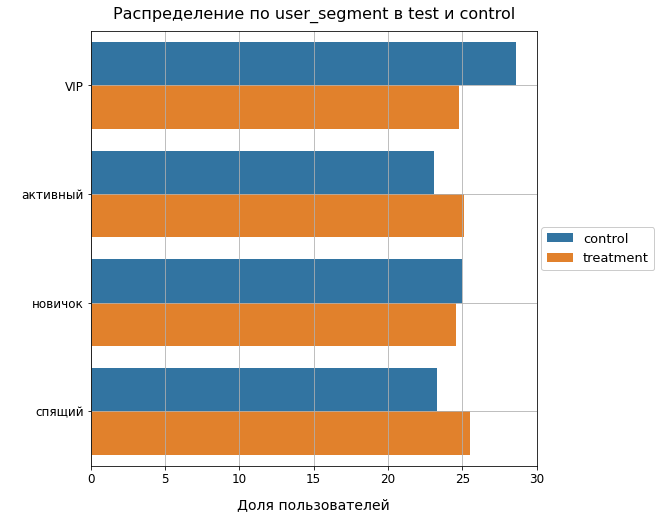

Нет статистически значимой разницы между долями VIP в группах
Нет статистически значимой разницы между долями активный в группах
Нет статистически значимой разницы между долями новичок в группах
Нет статистически значимой разницы между долями спящий в группах





In [17]:
category_columns_users = [
    'gender', 'region', 
    'buyer_segment', 'os',
    'device', 'browser', 
    'user_segment'
]

for parameter in category_columns_users:
    groups_division(parameter)

**Промежуточный вывод:**
- По параметру device (устройство) между долями mobile (мобильное устройство) в группах есть стат. значимая разница
- По параметру device (устройство) между долями tablet (планшет) в группах есть стат. значимая разница
- По параметру user_segment (сегмент пользователей) есть статистически значимая разница между долями VIP-пользователей в группах

Учитывая, что работаем с данными маркетплейса, используемое устройство и сегмент пользователя могут иметь значение, т.к. 
- веб-версия и приложение могут отличаться друг от друга / веб-версия может не быть адаптирована под маленькие размеры экранов
- VIP-пользователи активнее других пользователей

Будем учитывать это при подведении результатов A/B-теста

### 1.3 Вывод по анализу аудитории эксперимента

- контрольная и тестовая группы не пересекаются
- размеры групп близки, нет статистически значимой разницы между долями в группах
- есть статистически значимая разница между долями различных устройств в тестовой и контрольной группах (мобильные устройства и планшеты), а также в контрольной группе больше VIP-пользователей, чем в тестовой; эти различия необходимо учитывать при интерпретации результатов A/B-эксперимента

### 2.1 Сравнение воронок событий в тестовой и контрольной группах

Объединим датасеты events_AB и AB_split_users, изучим классическую и пошаговую воронки событий в тестовой и контрольной группах

In [18]:
events_AB_with_group = pd.merge(
    events_AB,
    AB_split_users,
    how='left',
    on='user_id'
)

display_with_heading(
    'events_AB с информацией о группе',
    events_AB_with_group.head()
)

events_AB с информацией о группе:


,event_id,session_id,user_id,event_date,event_type,os,device,event_index,user_segment,product_name,event_week,event_month,group
0,844987,135457,45076,2025-01-02 03:25:32,page_view,Android,tablet,1,regular,NaN,2024-12-30,2025-01-01,control
1,844988,135457,45076,2025-01-02 03:25:49,product_view,Android,tablet,2,regular,Картина маслом,2024-12-30,2025-01-01,control
2,844989,135457,45076,2025-01-02 03:26:23,product_click,Android,tablet,3,regular,Сумка кожаная,2024-12-30,2025-01-01,control
3,844990,135457,45076,2025-01-02 03:26:50,add_to_cart,Android,tablet,4,regular,Дезодорант,2024-12-30,2025-01-01,control
4,844991,135457,45076,2025-01-02 03:27:11,checkout_start,Android,tablet,5,regular,NaN,2024-12-30,2025-01-01,control


Эксперимент направлен на повышение конверсии из регистрации в первую покупку, поэтому изучим следующие пользовательские события:

1. 'registration' — см. пояснение ниже
2. 'product_view'
3. 'product_click'
4. 'add_to_cart'
5. 'checkout_start'
6. 'checkout_complete'
7. 'order_complete' — см. пояснение ниже

В датафрейме с событиями регистрации нет, поэтому кол-во зарегистрированных пользователей добавим вручную после группировки датафрейма events по событиям. Также кол-во уникальных пользователей, совершивших 'checkout_complete', не совпадает с кол-вом уникальных пользователей в таблице с заказами. Кол-во уникальных пользователей, совершивших заказы, также добавим вручную. Для этого необходимо объединить датафрейм **orders_AB** с информацией о распределении пользователей по группам (датафрейм **AB_split_users**) и рассчитать кол-во уникальных пользователей, совершивших хотя бы одну покупку

In [19]:
orders_AB_with_group = pd.merge(
    orders_AB,
    AB_split_users,
    how='left',
    on='user_id'
)

display_with_heading(
    'Датафрейм orders_AB с инф-ей о группе',
    orders_AB_with_group.head()
)

Датафрейм orders_AB с инф-ей о группе:


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,group
0,37141,45065,2025-01-01 11:57:43,Цепочка серебряная,3,7202.01,21606.03,Украшения и часы,2024-12-30,2025-01-01,treatment
1,37148,45081,2025-01-01 16:01:22,Куртка детская,2,2156.91,4313.82,Детская одежда,2024-12-30,2025-01-01,treatment
2,37149,45081,2025-01-01 16:01:22,Джинсы детские,1,873.16,873.16,Детская одежда,2024-12-30,2025-01-01,treatment
3,37147,45077,2025-01-02 04:59:13,Корм для кошек,2,851.39,1702.78,Зоотовары,2024-12-30,2025-01-01,treatment
4,37146,45077,2025-01-02 04:59:13,Чай черный,2,239.45,478.90,Продукты питания,2024-12-30,2025-01-01,treatment


In [20]:
events_order = [
    'product_view',
    'product_click',
    'add_to_cart',
    'checkout_start',
    'checkout_complete'
]

reg_and_events_order = [
    'registration',
    'product_view',
    'product_click',
    'add_to_cart',
    'checkout_start',
    'checkout_complete',
    'order_complete'
]

In [21]:
funnel_groups = {}

# ранее отобрали шаги воронки
funnel_groups['event'] = reg_and_events_order

for group in ['control', 'treatment']:
    events_AB_with_group_slice = (
        events_AB_with_group[
            events_AB_with_group['group'] == group
        ]
    )
    
    funnel = (
        events_AB_with_group_slice
            .groupby('event_type')
            .agg(total_users=('user_id', 'nunique'))
            .reindex(events_order)
    )
    
    total_registrations = (
        group_sizes[
            group_sizes['group']==group
        ]['total_users'].iloc[0]
    )
    
    total_buyers = (
        orders_AB_with_group[
           orders_AB_with_group['group']==group 
        ]['user_id'].nunique()
    )
    
    regs = pd.DataFrame(data=total_registrations, index=['registration'], columns=['total_users'])
    buys = pd.DataFrame(data=total_buyers, index=['order_complete'], columns=['total_users'])
    
    funnel_with_reg = pd.concat([regs, funnel])
    
    funnel_with_reg_n_buy = pd.concat([funnel_with_reg, buys]).reset_index(names=['event'])
    
    display_with_heading(
        f'Кол-во пользователей в группе {group}, совершивших действие',
        funnel_with_reg_n_buy
    )
    
    funnel_with_reg_n_buy['users_%_from_first'] = round(
        100 * funnel_with_reg_n_buy['total_users'] 
        / funnel_with_reg_n_buy['total_users'].iloc[0], 1
    )

    funnel_with_reg_n_buy['users_%_from_prev'] = round(
        100 * funnel_with_reg_n_buy['total_users'] 
        / funnel_with_reg_n_buy['total_users'].shift(1), 1
    )
    
    funnel_groups[f'{group}_classic'] = funnel_with_reg_n_buy['users_%_from_first']
    funnel_groups[f'{group}_step_by_step'] = funnel_with_reg_n_buy['users_%_from_prev']
    
funnel_groups_df = pd.DataFrame(funnel_groups)

display_with_heading(
    'Путь пользователей в контрольной и тестовой группах:',
    funnel_groups_df
)

Кол-во пользователей в группе control, совершивших действие:


,event,total_users
0,registration,1503
1,product_view,257
2,product_click,245
3,add_to_cart,211
4,checkout_start,126
5,checkout_complete,79
6,order_complete,16


Кол-во пользователей в группе treatment, совершивших действие:


,event,total_users
0,registration,1465
1,product_view,230
2,product_click,225
3,add_to_cart,193
4,checkout_start,128
5,checkout_complete,85
6,order_complete,110


Путь пользователей в контрольной и тестовой группах::


,event,control_classic,control_step_by_step,treatment_classic,treatment_step_by_step
0,registration,100.0,NaN,100.0,NaN
1,product_view,17.1,17.1,15.7,15.7
2,product_click,16.3,95.3,15.4,97.8
3,add_to_cart,14.0,86.1,13.2,85.8
4,checkout_start,8.4,59.7,8.7,66.3
5,checkout_complete,5.3,62.7,5.8,66.4
6,order_complete,1.1,20.3,7.5,129.4


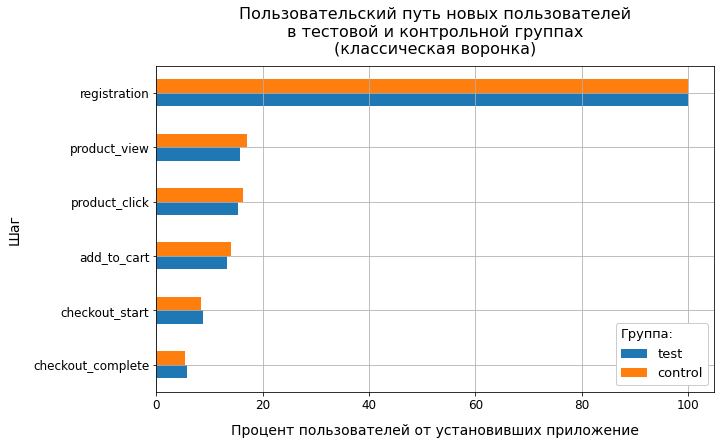

In [22]:
# визуализируем классическую воронку, 
# начиная с шага 'registration' и 
# заканчивая шагом 'checkout_complete'

funnel_groups_df[5::-1].plot.barh(
    y=['treatment_classic', 'control_classic'], 
    x='event',
    label=['test', 'control'],
    figsize=(10,6),
    grid=True,
)

plt.title(
    'Пользовательский путь новых пользователей'
    +'\nв тестовой и контрольной группах'
    +'\n(классическая воронка)',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Процент пользователей от установивших приложение',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Шаг',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)

plt.grid()
plt.legend(
    fontsize=13,
    title='Группа:',
    title_fontsize=13,
    alignment='left',
    framealpha=1,
)

plt.legend(
    fontsize=13,
    title='Группа:',
    title_fontsize=13,
    alignment='left',
    framealpha=1,
)

plt.grid()

plt.show()

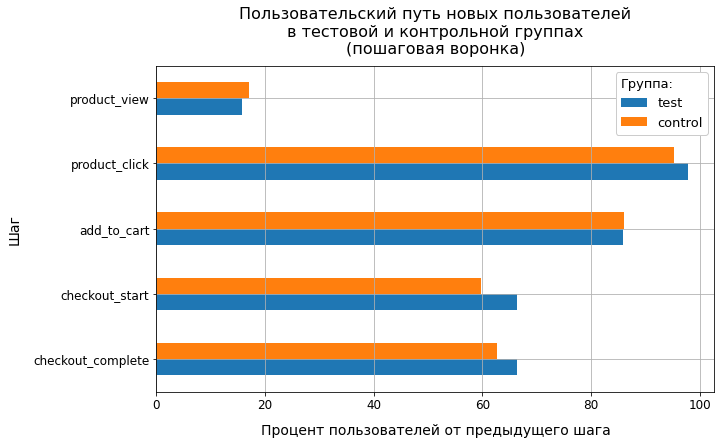

In [23]:
# визуализируем пошаговую воронку, 
# начиная с шага 'product_view'
# и заканчивая 'checkout_complete'

funnel_groups_df[5:0:-1].plot.barh(
    y=['treatment_step_by_step', 'control_step_by_step'], 
    x='event',
    label=['test', 'control'],
    figsize=(10,6),
    grid=True,
)

plt.title(
    'Пользовательский путь новых пользователей'
    +'\nв тестовой и контрольной группах'
    +'\n(пошаговая воронка)',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Процент пользователей от предыдущего шага',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Шаг',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)

plt.grid()
plt.legend(
    fontsize=13,
    title='Группа:',
    title_fontsize=13,
    alignment='left',
    framealpha=1,
)

plt.legend(
    fontsize=13,
    title='Группа:',
    title_fontsize=13,
    alignment='left',
    framealpha=1,
)

plt.grid()

plt.show()

### 2.2 Вывод по сравнению пути пользователя в тестовой и контрольной группах

1. Основная просадка на пути от регистрации к завершению оформления заказа — мало пользователей доходит до просмотра товаров. Возможно, пользователям показывают товары, которые их не интересуют; возможно, пользователи не используют фильтр по категории товара или категорий товаров; возможно, пользователи в принципе не заходят на маркетплейс после регистрации. Поэтому разница в кол-ве пользователей, дошедших от показа товара до оформления заказа, составляет менее процента между тестовой и контрольной группой. Исправление нижней части воронки "теряется" в проседающей верхней части
2. Шаги начала и завершения чекаута имеют бóльшую конверсию с предыдущего шага в тестовой группе, чем в контрольной, на 7% и 4% соответственно. Данные изменения в пути пользователя могут повлиять на ключевую метрику —  конверсию в первую покупку. Проведем анализ метрик, как запланировано

### 3.1 Анализ метрик А/В-эксперимента

#### 3.1.1 Ключевая метрика — используем таблицу с заказами

Ключевая метрика — конверсия в первую покупку — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку

В рамках статистического теста:
1. формулируем нулевую и альтернативную гипотезы
2. определяем уровень статистической значимости (выберем α = 0.05)
3. рассчитываем p-value
4. сравниваем p-value с выбранным уровнем значимости и принимаем решение по отклонению или принятию нулевой гипотезы

Ожидалось, что ключевая метрика вырастет. Исходя из этого **запишем нулевую и альтернативную гипотезу**:<br>
- H<sub>0</sub>: значение конверсии из регистрации в первую покупку в тестовой группе не отличается от значения в контрольной<br>
- H<sub>1</sub>: значение конверсии из регистрации в первую покупку в тестовой группе выше значения в контрольной (односторонняя альтернативная гипотеза)

Данные о кол-ве зарегистрированных пользователей хранятся в датафрейме **users_AB_with_group**, данные о кол-ве заказов — в датафрейме **orders_AB_with_group**. Рассчитаем кол-во уникальных зарегистрировавшихся пользователей в каждой из групп и кол-во уникальных пользователей, совершивших заказ, в каждой из групп. Используем эти значения при проведении Z-теста пропорций для двух групп. Будем использовать именно информацию из датафрейма **orders_AB_with_group**, а не кол-во пользователей, совершивших "checkout_complete" (завершение оформления заказа), т.к. заказ можно, например, отменить / не забрать и т.д.

In [24]:
users_reg = (
    users_AB_with_group
        .groupby('group')
        .agg(total_users=('user_id', 'nunique'))
        .reset_index()
)

display_with_heading(
    'Кол-во зарегистрированных пользователей',
    users_reg
)

buyers = (
    orders_AB_with_group
        .groupby('group')
        .agg(total_buyers=('user_id', 'nunique'))
        .reset_index()
)

display_with_heading(
    'Кол-во пользователей, совершивших хотя бы одну покупку',
    buyers
)

Кол-во зарегистрированных пользователей:


,group,total_users
0,control,1503
1,treatment,1465


Кол-во пользователей, совершивших хотя бы одну покупку:


,group,total_buyers
0,control,16
1,treatment,110


In [25]:
alpha = 0.05

control_reg = int(
    users_reg[users_reg.group == 'control']['total_users'].iloc[0]
)

test_reg = int(
    users_reg[users_reg.group == 'treatment']['total_users'].iloc[0]
)

control_buy = int(
   buyers[buyers.group == 'control']['total_buyers'].iloc[0]
)
test_buy = int(
   buyers[buyers.group == 'treatment']['total_buyers'].iloc[0]
)

stat_barrier, pval_barrier = proportions_ztest(
    [control_buy, test_buy],
    [control_reg, test_reg],
    alternative='smaller'
)

if pval_barrier < alpha:
    print(f'Ключевая метрика: p-value = {round(pval_barrier, 2)} < alpha; отвергаем нулевую гипотезу')
else:
    print(f'Ключевая метрика: p-value = {round(pval_barrier, 2)} > alpha; не получилось отвергнуть нулевую гипотезу')

Ключевая метрика: p-value = 0.0 < alpha; отвергаем нулевую гипотезу


In [26]:
# выведем значения конверсии из регистрации
# в совершение заказа; абсолютную и
# относительную разницу между группами

CR_test = 100 * test_buy / test_reg

CR_control = 100 * control_buy / control_reg

abs_diff = CR_test - CR_control

rel_diff = 100 * (CR_test - CR_control) / CR_control

print(f'Конверсия в тестовой группе: {round(CR_test, 1)}%')
print(f'Конверсия в контрольной группе: {round(CR_control, 1)}%')
print(f'Абсолютная разница конверсий: {round(abs_diff, 1)}')
print(f'Относительная разница конверсий: {round(rel_diff, 1)}%')

Конверсия в тестовой группе: 7.5%
Конверсия в контрольной группе: 1.1%
Абсолютная разница конверсий: 6.4
Относительная разница конверсий: 605.3%


**Промежуточный вывод:** 
- Конверсия из регистрации в совершение первого заказа в тестовой группе: 7.5%
- Конверсия из регистрации в совершение первого заказа в контрольной группе: 1.1%
- Разница в 6,4 процента конверсии
- По результатам проведения Z-теста пропорций для двух групп отвергли нулевую гипотезу о разнице конверсий. Т.е. значение ключевой метрики в тестовой группе статистически значимо выше, чем в контрольной, эксперимент успешен

#### 3.1.2 Ключевая метрика — используем таблицу с событиями

In [27]:
# если будем учитывать событие 
# завершения оформления заказа
# вместо фактического заказа:

alpha = 0.05

control_reg = int(
    users_reg[users_reg.group == 'control']['total_users'].iloc[0]
)

test_reg = int(
    users_reg[users_reg.group == 'treatment']['total_users'].iloc[0]
)

control_buy = int(
   events_AB_with_group[
       (events_AB_with_group.group == 'control')
       & (events_AB_with_group.event_type == 'checkout_complete')
   ]['user_id'].nunique()
)

test_buy = int(
   events_AB_with_group[
       (events_AB_with_group.group == 'treatment')
       & (events_AB_with_group.event_type == 'checkout_complete')
   ]['user_id'].nunique()
)

stat_barrier, pval_barrier = proportions_ztest(
    [control_buy, test_buy],
    [control_reg, test_reg],
    alternative='smaller'
)

if pval_barrier < alpha:
    print(f'Ключевая метрика: p-value = {round(pval_barrier, 2)} < alpha; отвергаем нулевую гипотезу')
else:
    print(f'Ключевая метрика: p-value = {round(pval_barrier, 2)} > alpha; не получилось отвергнуть нулевую гипотезу')
    
# выведем значения конверсии из регистрации
# в совершение заказа; абсолютную и
# относительную разницу между группами

CR_test = 100 * test_buy / test_reg

CR_control = 100 * control_buy / control_reg

abs_diff = CR_test - CR_control

rel_diff = 100 * (CR_test - CR_control) / CR_control

print(f'Конверсия в тестовой группе: {round(CR_test, 1)}%')
print(f'Конверсия в контрольной группе: {round(CR_control, 1)}%')
print(f'Абсолютная разница конверсий: {round(abs_diff, 1)}')
print(f'Относительная разница конверсий: {round(rel_diff, 1)}%')

Ключевая метрика: p-value = 0.26 > alpha; не получилось отвергнуть нулевую гипотезу
Конверсия в тестовой группе: 5.8%
Конверсия в контрольной группе: 5.3%
Абсолютная разница конверсий: 0.5
Относительная разница конверсий: 10.4%


**Промежуточный вывод:**
- если смотреть на кол-во пользователей, завершивших оформление заказа, то конверсия из регистрации в первый заказ в тестовой группе на 10% выше, чем в контрольной. По результатам Z-теста пропорций для двух групп рост статистически не значим. Т.е. условие успешности эксперимента не удовлетворено

#### 3.1.3 Барьерная метрика

Барьерная метрика — общая выручка от пользователей канала TikTok. Для расчета воспользуемся датафреймом **orders_AB_with_group**. Учитывая, что единственный критерий успеха эксперимента — статистически значимый рост конверсии в ключевой группе, можем сравнить метрику в группах между собой и провести статистический тест при ухудшении метрики в тестовой группе

In [28]:
total_income = (
    orders_AB_with_group
        .groupby('group')
        .agg(total_income=('total_price', 'sum'))
        .reset_index()
)

display_with_heading(
    'Общая выручка в тестовой и контрольной группах',
    total_income
)

Общая выручка в тестовой и контрольной группах:


,group,total_income
0,control,378372.90
1,treatment,3845597.03


**Промежуточный вывод:** в тестовой группе рост общей выручки на порядок

#### 3.1.4 Вспомогательная метрика 1 

Средняя выручка на пользователя. Учитывая, что единственный критерий успеха эксперимента — статистически значимый рост конверсии в ключевой группе, можем сравнить метрику в группах между собой и провести статистический тест при ухудшении метрики в тестовой группе
Кол-во зарегистрированных пользователей было расчитано ранее, общая выручка тоже. Рассчитаем среднюю выручку на пользователя

In [29]:
ARPU = pd.merge(
    total_income,
    group_sizes,
    how='left',
    on='group'
)

ARPU['arpu'] = (
    ARPU['total_income']
    / ARPU['total_users']
)

display_with_heading(
    'Выручка на пользователя в тестовой и контрольной группах',
    ARPU[['group', 'arpu']]
)

Выручка на пользователя в тестовой и контрольной группах:


,group,arpu
0,control,251.745110
1,treatment,2624.980908


**Промежуточный вывод:** в тестовой группе рост выручки на пользователя на порядок

#### 3.1.5 Вспомогательная метрика 2

Средняя выручка на покупателя. Общая выручка и кол-во покупателей были рассчитано ранее. Учитывая, что единственный критерий успеха эксперимента — статистически значимый рост конверсии в ключевой группе, можем сравнить метрику в группах между собой и провести статистический тест при ухудшении метрики в тестовой группе

In [30]:
ARPPU = pd.merge(
    total_income,
    buyers,
    how='left',
    on='group'
)

ARPPU['arppu'] = (
    ARPPU['total_income']
    / ARPPU['total_buyers']
)

display_with_heading(
    'Выручка на платящего пользователя в тестовой и контрольной группах',
    ARPPU[['group', 'arppu']]
)

Выручка на платящего пользователя в тестовой и контрольной группах:


,group,arppu
0,control,23648.30625
1,treatment,34959.97300


**Промежуточный вывод:** в тестовой группе рост выручки на платящего пользователя примерно в 1.5 раза

#### 3.1.6 Вспомогательная метрика 3

Средний чек. В таблице **orders_AB_with_group** каждая строка — отдельный заказ. Рассчитаем среднее по общей стоимости заказа. Учитывая, что единственный критерий успеха эксперимента — статистически значимый рост конверсии в ключевой группе, можем сравнить метрику в группах между собой и провести статистический тест при ухудшении метрики в тестовой группе

In [31]:
aov = (
    orders_AB_with_group
        .groupby('group')
        .agg(aov=('total_price', 'mean'))
        .reset_index()
)

display_with_heading(
    'Средняя стоимость заказа в тестовой и контрольной группах',
    aov
)

Средняя стоимость заказа в тестовой и контрольной группах:


,group,aov
0,control,15765.53750
1,treatment,16647.60619


**Промежуточный вывод:** в тестовой группе рост средней стоимости заказа примерно на 5%

### Вывод по анализу метрик

Ключевая метрика — конверсия в первую покупку — можеи быть интерпретирована по-разному. Ее можно рассчитать из кол-ва покупателей по таблице с заказами (orders) или из кол-ва пользователей в таблице с событиями (events), которые дошли до шага "checkout_complete" (обычно означает завершение оформления заказа)

В первом случае ключевая метрика статистически значимо выросла: в контрольной группе составляла 1%, в тестовой — 7,5%. Статистическая значимость роста конверсии была проверена Z-тестом пропорций для двух групп.

Во втором случае статистически значимого роста метрики выявить не удалось. Конверсия в тестовой группе — 5.8%, в контрольной группе: 5.3%.

Барьерные и вспомогательные метрики не ухудшились.

Вывод об успехе эксперимента различен в зависимости от того, что понималось под ключевой метрикой. Я склоняюсь к первому варианту, т.к. завершение оформления заказа не всегда означает завершение заказа (может быть оформлен возврат / пользователь может не забрать заказ из пункта выдачи). Исходя их этого предлагаю следующие

### Рекомендации
1. Новую фичу ввести для пользователей, приходящих из канала TikTok. Фича требует поэтапного внедрения с мониторингом долгосрочных эффектов и unit-экономики. Риски:
    - Привыкание к бонусам (снижение органической конверсии)
    - Каннибализация (пользователи, которые купили бы без бонуса)
    - Мошенничество (мультиаккаунты для получения бонусов)

2. в дальнейшем изучить конверсию из зарегистрированного в активного пользователя (она ниже, чем в других каналах и сильно ухудшает верхнюю часть воронки)